In [1]:
from mpi4py import MPI
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from h5 import HDFArchive
import coqui

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-27 18:46:32.990016
/mnt/home/cyeh/Projects/triqs/ctseg.src/build/nn_nu_0524/install/lib/python3.11/site-packages/triqs_ctseg/solver.py:7: FutureWarning: The triqs.gf module has been renamed to triqs.gfs. Please update your imports. triqs.gf will be removed in a future version.
  from .solver_core import SolverCore


## Ab Initio GW+EDMFT for Quantum Materials

<figure style="text-align: center;">
 <img src="../../images/nio_gw_edmft_summary.png" alt="Hilbert space partitioning in GW+EDMFT" width="80%">
 <figcaption><em>Figure&nbsp;1:</em> Hilbert-space partitioning in GW+EDMFT. The full single-particle space $\mathcal{B}$ is treated at the GW level, while a low-energy correlated subspace $\mathcal{C}$ is treated nonperturbatively with EDMFT. A double-counting term removes the contribution that GW already includes on $\mathcal{C}$.</figcaption>
</figure>

This tutorial introduces the ab initio GW+EDMFT workflow in CoQuí using cubic NiO as an example.

**Why go beyond GW?** As we saw in [Tutorial 02](../02_gw/02_gw_electronic_structure.ipynb), GW is a perturbative theory built on the random phase approximation (RPA). It works well for weakly to moderately correlated materials, but it breaks down when local correlations dominate the low-energy physics, such as the opening of a Mott gap or the satellite features of correlated metals. NiO is a prototypical example: a charge-transfer insulator with strong Ni $3d$–O $2p$ hybridization whose insulating gap, opened primarily in the Ni $e_g$ orbitals, is driven by local correlations that neither DFT nor GW alone fully captures. 

**Quantum embedding as the remedy.** The idea of quantum embedding is to split the Hilbert space into two parts and treat each at the level of theory it requires: a large environment $\mathcal{B}\backslash\mathcal{C}$ in which weak, nonlocal correlations dominate, and a small correlated subspace $\mathcal{C}$ in which local, nonperturbative correlations must be handled exactly. In GW+EDMFT, $\mathcal{B}$ is treated with GW and $\mathcal{C}$ is treated with *extended* dynamical mean-field theory (EDMFT), which maps the local $\mathcal{C}$ space onto an impurity problem with a dynamic local interaction $\mathcal{U}(i\Omega_n)$ in addition to the local hybridization encoded in the Weiss field $\mathcal{G}(i\omega_n)$. 

This decomposition is made rigorous by the Almbladh free-energy functional, which expresses the total free energy of the system as

$$
\Psi[G,W] \approx \Psi^{GW+\mathrm{EDMFT}}[G,W] = \Psi^{\mathrm{GW}}_{\mathcal{B}}[G,W] + \Psi^{\mathrm{EDMFT}}_{\mathcal{C}}[G,W] - \Psi^{\mathrm{DC}}_{\mathcal{C}}[G,W]. 
$$

Here, $\Psi^{\mathrm{GW}}_{\mathcal{B}}$ is the GW free energy evaluated on the full space, $\Psi^{\mathrm{EDMFT}}_{\mathcal{C}}$ adds the local EDMFT correction restricted to $\mathcal{C}$, and $\Psi^{\mathrm{DC}}_{\mathcal{C}}$ (the so-called double-counting correction) removes the part that GW has already accounted for inside $\mathcal{C}$ so that no diagram is counted twice.

**Self-consistency equations.** Stationarity of $\Psi^{\mathrm{GW+EDMFT}}$ with respect to $G$ and $W$ yields the GW+EDMFT self-consistency equations implemented in CoQui. The lattice self-energy and polarization follow from the functional derivatives $\Sigma=\delta\Psi/\delta G$ and $\Pi=-2\,\delta\Psi/\delta W$, which inside the Almbladh decomposition take the form

$$
\begin{aligned}
\Sigma^{\mathbf{k}} &= \Sigma_{\mathrm{GW}}^{\mathbf{k}} + C^{\mathbf{k}\dagger} \left[\, \tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}} \,\right] C^{\mathbf{k}}, \\
\Pi^{\mathbf{q}}    &= \Pi_{\mathrm{GW}}^{\mathbf{q}}    + B^{\mathbf{q}\dagger}\left[\, \tilde{\Pi}_{\mathrm{imp}}    - \tilde{\Pi}_{\mathrm{DC}}    \,\right] B^{\mathbf{q}}.
\end{aligned}
$$

Here $C^{\mathbf{k}}$ and $B^{\mathbf{q}}$ are the fermionic and bosonic projectors that map one- and two-particle quantities from the full space $\mathcal{B}$ onto the correlated subspace $\mathcal{C}$, and tildes denote quantities defined inside $\mathcal{C}$. In CoQuí, $C^{\mathbf{k}}$ is the MLWF projector and $B^{\mathbf{q}}$ is its two-particle counterpart for the bosonic (polarization / screened-interaction) channel.

The lattice GW contributions $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ are evaluated on the full Hilbert space $\mathcal{B}$ using the cubic-scaling THC/ISDF algorithm of [arXiv:2401.12308](https://arxiv.org/pdf/2401.12308) (see Tutorial 02). The double-counting terms

$$
\tilde{\Sigma}_{\mathrm{DC}} = \tilde{G}_{\mathrm{loc}}\,\tilde{W}_{\mathrm{loc}}, \qquad
\tilde{\Pi}_{\mathrm{DC}}    = -\tilde{G}_{\mathrm{loc}}\,\tilde{G}_{\mathrm{loc}},
$$

represent the same GW diagrams evaluated using the *locally projected* propagators

$$
\tilde{G}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{k}} C^{\mathbf{k}}\, G^{\mathbf{k}}\, C^{\mathbf{k}\dagger}, \qquad
\tilde{W}_{\mathrm{loc}} = \textstyle\sum_{\mathbf{q}} B^{\mathbf{q}}\, W^{\mathbf{q}}\, B^{\mathbf{q}\dagger},
$$

so that the bracketed corrections in the master equations above isolate the *beyond-GW* impurity contribution to the lattice self-energy and polarization.

The impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and polarization $\tilde{\Pi}_{\mathrm{imp}}$ are obtained by solving an EDMFT impurity action

$$
\begin{split}
 \mathcal{S} &= \iint_0^{\beta} d\tau\, d\tau' \sum_{a,b} c^{\dagger}_{a}(\tau)\,\tilde{\mathcal{G}}^{-1}_{ab}(\tau-\tau')\,c_{b}(\tau') \\
 &+ \frac{1}{2}\iint_0^{\beta} d\tau\, d\tau' \sum_{a,b,c,d} \tilde{\mathcal{U}}_{abcd}(\tau-\tau')\, c^{\dagger}_{a}(\tau)\, c^{\dagger}_{c}(\tau')\, c_{d}(\tau')\, c_{b}(\tau),
\end{split}
$$

in which the fermionic and bosonic Weiss fields are related to the local propagators by the impurity Dyson equations

$$
\tilde{\mathcal{G}}^{-1}(i\omega_{n}) = \tilde{G}_{\mathrm{loc}}^{-1}(i\omega_{n}) + \tilde{\Sigma}_{\mathrm{imp}}(i\omega_{n}), \qquad
\tilde{\mathcal{U}}^{-1}(i\Omega_{n}) = \tilde{W}_{\mathrm{loc}}^{-1}(i\Omega_{n}) + \tilde{\Pi}_{\mathrm{imp}}(i\Omega_{n}).
$$

The action is then solved with a numerically exact continuous-time quantum Monte Carlo (CT-QMC) solver.

The EDMFT corrections $[\tilde{\Sigma}_{\mathrm{imp}} - \tilde{\Sigma}_{\mathrm{DC}}]$ and $[\tilde{\Pi}_{\mathrm{imp}} - \tilde{\Pi}_{\mathrm{DC}}]$ are then upfolded back to $\mathcal{B}$ through the projectors, after which the lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are updated through their Dyson equations 

$$
\begin{aligned}
&G^{\mathbf{k}}(i\omega_{n}) = \left[ G^{\mathbf{k},-1}_{0}(i\omega_{n}) - \Sigma^{\mathbf{k}}(i\omega_{n})\right]^{-1}\\
&W^{\mathbf{q}}(i\Omega_{n}) = \left[ V^{\mathbf{q},-1} - \Pi^{\mathbf{q}}(i\Omega_{n})\right]^{-1},
\end{aligned}
$$

which completes one iteration of the GW+EDMFT loop. 

A new iteration is started using the updated lattice propagators to compute a new GW self-energy and polarization as well as the EDMFT corrections. The procedure is iterated until 

$$
\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}, \qquad
\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}.
$$

### Section 1: Ab initio GW+EDMFT in CoQui

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_cartoon.png" alt="Self-consistent GW+EDMFT workflow" width="80%">
 <figcaption><em>Figure&nbsp;2:</em> Self-consistent GW+EDMFT workflow in CoQui.</figcaption>
</figure>

Figure 2 summarizes how the ab initio GW+EDMFT self-consistency equations are organized as an iterative workflow in CoQui. The loop does not start from scratch: the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ are taken from a preceding GW calculation, which already provides a physically reasonable starting point for the GW+EDMFT loop. 

Starting from this initial pair $(G^{\mathbf{k}}, W^{\mathbf{q}})$, CoQui treats the lattice GW update and the impurity EDMFT update as decoupled workflow components. The GW update, shown by the yellow and green boxes in Fig. 2, computes the lattice self-energy $\Sigma_{\mathrm{GW}}^{\mathbf{k}}$ and polarization $\Pi_{\mathrm{GW}}^{\mathbf{q}}$ in the full space $\mathcal{B}$. The EDMFT update, shown by the yellow and blue boxes, projects the current lattice quantities onto the correlated subspace $\mathcal{C}$, constructs the corresponding impurity problem, and computes the impurity self-energy $\tilde{\Sigma}_{\mathrm{imp}}$ and impurity polarization $\tilde{\Pi}_{\mathrm{imp}}$. 

This separation gives users explicit control over the self-consistency strategy. For example, one may perform several GW updates before solving the impurity problem again, or perform several EDMFT impurity updates while keeping the lattice GW quantities fixed. This flexibility is useful because the lattice and impurity sectors often have different numerical costs and convergence behavior. 

>Note that CoQuí does not have its own impurity solver. Instead, an ab initio impurity problem, defined by the fermionic and bosonic Weiss fields $\tilde{\mathcal{G}}$ and $\tilde{\mathcal{U}}$, is constructed and passed to an external solver, which returns $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ back to CoQuí for the next iteration. Currently, CoQuí interfaces with the [continuous-time quantum Monte Carlo (CT-QMC) solvers](https://github.com/TRIQS/ctseg) of the [TRIQS](https://triqs.github.io/) libraries. We will return to the specific controls for the CT-QMC solver in the GW+EDMFT execution section below.

**Outline of this notebook**

1. How to launch a GW+EDMFT calculation from a precomputed GW checkpoint using `coqui.dmft.run_gw_edmft`, and the most important input parameters that control the loop.

2. How to read and interpret the lattice (`{prefix}.mbpt.h5`) and impurity (`{prefix}.dmft.h5`) checkpoints produced by the driver.

3. How spectral functions, local self-energies, and effective interactions for NiO evolve from the GW starting point to the converged GW+EDMFT solution, and how the GW+EDMFT screened interaction compares to cRPA.

First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `nio_555/` (QE and Wannier90 outputs for 5x5x5 NiO)

In [54]:
%%bash
python copy_notebook_inputs.py

Removed directory: nio_555
Removed file: nio.mbpt.h5
Copied: data/qe_inputs/nio/555 -> nio_555
Copied: data/coqui/nio/555/nio.mbpt.h5 -> nio.mbpt.h5
Notebook inputs are ready.


#### 🔹 Initialization Step - GW calculation

A GW+EDMFT calculation must start from an existing GW checkpoint, which provides the initial lattice $G^{\mathbf{k}}$ and $W^{\mathbf{q}}$ for the loop. The setup of such a calculation is covered in [Tutorial 02](../02_gw/02_gw_electronic_structure.ipynb), so we will not repeat it here. 

Instead, in this tutorial, we will perform the GW+EDMFT calculation using 

- A precomputed self-consistent GW checkpoint (`nio.mbpt.h5`) for NiO on a 5x5x5 k-mesh. 

- The MLWFs (Ni $d$ / O $p$) provided in: `nio_555/mlwf_dp/nio.mlwf.h5`. 

##### Local spectral function projected onto MLWFs
It is instructive to inspect how the MLWFs contribute to the low-energy states of the GW solution. For this purpose, we can use the post-processing routine `coqui.post_proc.local_dos` to compute the local spectral function projected onto the MLWFs (Ni $d$ / O $p$) orbitals. As we will see, this exposes the *incorrect metallic* GW solution and motivates the GW+EDMFT correction that follows.

>```python
>coqui.post_proc.local_dos(mf : Mf, params : dict)
>```

Function inputs:
- `mf`: `Mf` object of the simulation system.

- `params`: dictionary of interpolation parameters. Key parameters include:
    - `outdir` / `prefix`: GW checkpoint file, `{outdir}/{prefix}.mbpt.h5`.
    
    - `wannier_file` (required): MLWF file that defines the local subspace.

    - `w_min` / `w_max` (default: -0.367, 0.367 a.u.): real-frequency range for the spectral function.

    - `eta` (default: pi/beta a.u.): broadening applied in the analytic continuation.

Function outputs:
- The k-resolved Green's function on the uniform k-grid, projected onto the MLWFs, is written back into the same MBPT checkpoint used as input.

    - Imaginary-frequency data are stored under `scf/iter{iteration}/ac/G_wskab_fbz/input`.

    - Real-frequency continuation results are stored under `scf/iter{iteration}/ac/G_wskab_fbz/output`.

  The local spectral function can then be obtained from the real-frequency Green's function as $A(\omega) = -\frac{1}{\pi}\mathrm{Im}\,G(\omega+i\eta)$.

> Tip: `local_dos` continues the Green's function from the imaginary to the real axis with the Padé approximation by default. Since the imaginary-axis Green's function is also stored in the checkpoint, you can instead apply your own analytic-continuation workflow to the same data.

In [56]:
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

mf_params = {
    "prefix": "nio",
    "outdir": "nio_555/out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Spectral functions from full-frequency self-energy
winter_params = {
    "outdir": "./",
    "prefix": "nio",
    "wannier_file": "nio_555/mlwf_dp/nio.mlwf.h5",
    "w_min": -0.30,
    "w_max": 0.20,
    "eta": 0.005, 
}
coqui.post_proc.local_dos(mf=mf, params=winter_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (5,5,5)
  K-points                       = 125 total, 10 in the IBZ
  Number of electrons            = 24.0
  Electron density energy cutoff = 400.000 a.u. | FFT mesh = (36,36,36)
  Wavefunction energy cutoff     = 58.981 a.u. | FFT mesh = (19,19,19), Number of PWs = 2733

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 100.0 a.u.
  Frequency cutoff       = 5.10678741443889 a.u.
  Lambda                 = 510.678741443889
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 44, 44, 44, 45

  Projector Information
  ---------------------
  Number of impurities                      = 1
  Number of local orbitals per impurity     = 8
  Range of primary orbitals for local basis = [5

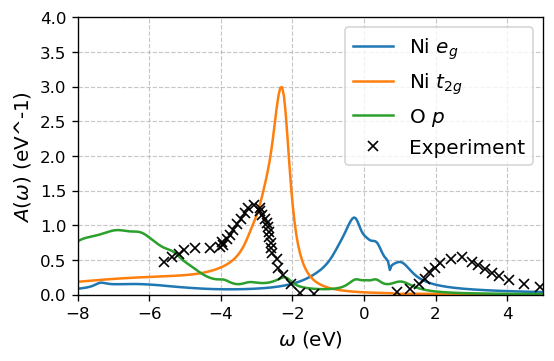

In [7]:
with HDFArchive("nio.mbpt.h5", "r") as ar:
    w_mesh = ar["scf/iter8/ac/G_wskab_fbz/w_mesh"] * Hartree_eV
    Gw = ar["scf/iter8/ac/G_wskab_fbz/output"] / Hartree_eV
    
Aloc = -np.sum(Gw.imag, axis=(1, 2)) / Gw.shape[2] * 2.0 / np.pi
A_eg = Aloc[:,0] + Aloc[:,1]
A_t2g = Aloc[:,2] + Aloc[:,3] + Aloc[:,4]
A_p = Aloc[:,5] + Aloc[:,6] + Aloc[:,7]

tot_pes = np.load("../../data/coqui/nio/555/nio_pes.npy")
tot_xas = np.load("../../data/coqui/nio/555/nio_xas.npy")

fig, ax = plt.subplots(1, figsize=(5,3), dpi=120)
ax.plot(w_mesh.real, A_eg, label='Ni $e_g$')
ax.plot(w_mesh.real, A_t2g, label='Ni $t_{2g}$')
ax.plot(w_mesh.real, A_p, label='O $p$')
ax.plot(tot_pes[:,0], tot_pes[:,1], color='black', marker='x', linestyle='', label='Experiment')
ax.plot(tot_xas[:,0], tot_xas[:,1], color='black', marker='x', linestyle='')

ax.set_xlim(-8.0, 5.0)
ax.set_ylim(0, 4.0)
ax.set_xlabel("$\omega$ (eV)", fontsize=12)
ax.set_ylabel("$A(\omega)$ (eV^-1)", fontsize=12)
ax.legend(ncol=1, loc=1, fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.show()

The plot above shows the GW local spectral function projected onto the Ni $e_g$, Ni $t_{2g}$, and O $p$ MLWFs. Two observations are relevant for setting up the GW+EDMFT calculation. First, the Ni $3d$ and O $2p$ weight strongly overlap over a wide energy window, reflecting the substantial $d$–$p$ hybridization characteristic of charge-transfer materials. Second, the Ni $e_g$ manifold and O $p$ orbitals both have finite spectral weight at the Fermi level, in contrast to the experimentally observed insulating state.

Based on this observation, we define the correlated subspace $\mathcal{C}$ to consist of only the Ni $e_g$ MLWFs (stored in `nio_555/mlwf_dp/nio_eg.mlwf.h5`). These orbitals dominates the low-energy spectral weight at the Fermi level and are the primary orbitals in which the Mott gap is expected to open. 
The remaining Ni $t_{2g}$ and O $p$ degrees of freedom are retained in the $GW$ level. 

#### 🔹 GW+EDMFT execution

Starting from a GW checkpoint and a correlated subspace $\mathcal{C}$ defined by the MLWFs, a GW+EDMFT calculation is launched by calling the single `coqui.dmft.run_gw_edmft` function: 

> ```
> coqui.dmft.run_gw_edmft(h_int: ThcCoulomb, embedding: ModEST.Embedding, params: dict)
> ```

Function inputs:
- `h_int`: `ThcCoulomb` instance containing the lattice Coulomb Hamiltonian used in the GW updates.

- `embedding`: `ModEST.Embedding` instance defining the correlated low-energy subspace $\mathcal{C}$ treated at the impurity level.

- `params`: dictionary containing the GW+EDMFT run settings. The most important entries for this tutorial are:

    - `outdir` (default: `"./"`): output directory for the generated checkpoint files.

    - `prefix` (required): file prefix used for the checkpoint `{prefix}.mbpt.h5`.

    - `niter` (required): number of outer GW+EDMFT iterations to perform.

    - `gw_iter_per_loop` (default: 1): number of GW updates per outer GW+EDMFT iteration. 

    - `edmft_iter_per_loop` (default: 1): number of EDMFT impurity updates per outer GW+EDMFT iteration.

    - `wannier_file` (required): MLWF HDF5 archive that defines the correlated subspace $\mathcal{C}$. 

    - `screen_type` (default: `"gw_edmft"`): screening prescription used to build the lattice irreducible polarization.

    - `edmft["chkpt_h5"]` (optional; default: write impurity data into `{outdir}/{prefix}.mbpt.h5`): redirect the impurity inputs and solver results to a separate HDF5 file. 

    - `edmft["impurity"]` (required): impurity-solver configuration block. See the note below for the most important CT-SEG controls.

> When `screen_type="rpa"`, polarization is updated using the RPA expression:
>$$
>\Pi^{\mathbf{q}} = -\textstyle\sum_{\mathbf{k}} G^{\mathbf{k}} G^{\mathbf{k}+\mathbf{q}}
>$$
>without adding the EDMFT correction. As a consequence, the bosonic EDMFT self-consistency condition is no longer enforced: 
>$$
>\tilde{W}_{\mathrm{loc}} \neq \tilde{W}_{\mathrm{imp}}.
>$$
>The EDMFT correction to the self-energy is still included, so the fermionic self-consistency condition
>$$
>\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}
>$$
>is still imposed. This simplified scheme is useful for stabilizing the initial stage of a GW+EDMFT iteration. In early iterations especially for Mott insulators, the impurity polarization can be unstable especially for the bosonic Weiss filed is far from converged. This allows the fermionic EDMFT loop to relax first. Once the calculation is stable, one can then switch to the full GW+EDMFT screening update.  

> **Note on the impurity solver.** The EDMFT step solves a quantum impurity model with retarded interations. CoQuí drives this via TRIQS/ctseg, a continuous-time hybridization-expansion quantum Monte Carlo solver, which natively supports density–density retarded interactionsd. The CT-SEG controls you will most often touch — all set inside `edmft["impurity"]` — fall into three groups:
>
> - **Monte Carlo statistics** (`n_cycles`, `n_warmup_cycles`, `length_cycle`): total measurement cycles across MPI, warmup cycles for equilibration, and updates between successive measurements. Together they set the statistical error on $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$.
>
> - **High-frequency tail fit** (`perform_tail_fit`, `fit_min_w`, `fit_max_w`, `fit_max_moment`): fit the noisy high-Matsubara tail of $\tilde{\Sigma}_{\mathrm{imp}}$ with an analytic $\mathcal{O}(1/i\omega_n)$ form. The fit is performed in the frequency window [`fit_min_w`, `fit_max_w`] with $\mathcal{O}(1/i\omega_n)$ up to order `fit_max_moment`. The high-frequency part of the self-energy (i.e. $w \ge $`fit_min_w`) is then replaced by the fit function. 
>
> - **Chemical-potential adjustment** (`chemical_potential["tolerance"]` and related sub-controls): controls the inner search for the impurity chemical potential that keeps the impurity occupancy consistent with the projected lattice value at every EDMFT iteration.

  
> **Trouble shooting tip**: 
> 1. If the EDMFT convergence does not get improved after increasing the number of Monte Carlo cycles systematically, you might need to revisit your tail fitting parameters: adjust the frequency window [`fit_min_w`, `fit_max_w`] or the fit order `fit_max_moment`. A poor fitting would lead to inaccurate self-energy, detarioting the convergence accuracy. 
>
> 2. If the chemical-potential tolerance is set too tight with respect to the QMC accuracy, the chemical potential search might fail 

Output:
- `{outdir}/{prefix}.mbpt.h5`: lattice checkpoint containing $G^{\mathbf{k}}$, $W^{\mathbf{q}}$, $\Sigma^{\mathbf{k}}$, $\Pi^{\mathbf{q}}$ and related quantities needed for post-processing and restart of the lattice side of the loop. **By default**, the impurity inputs and solver results are also appended to this file, so a single archive holds the complete state of the calculation.

- `edmft["chkpt_h5"]`: present only when `edmft["chkpt_h5"]` is set; in that case the impurity inputs and solver results are written here instead of being appended to the MBPT archive.

> For complete parameter options, use `help(coqui.dmft.run_gw_edmft)`. A full working setup used in this tutorial is collected in `gw_edmft.py`.

#### 🔹 Example - GW+EDMFT for NiO

Now we are ready to launch the GW+EDMFT calculation for NiO. 

Since the CT-QMC impurity solver is rather costly, we launch the calculation externally with MPI parallelization rather than calling `run_gw_edmft` directly inside the notebook. The full Python script is collected in `gw_edmft.py` (shown below). 

Run the script by executing the following command in the terminal: 

>```bash
>mpirun -np 5 python gw_edmft.py > gw_edmft.log
>```

in which the CT-QMC solver as well as all CoQui steps are parallelized across 5 MPI tasks. 

To keep the run further shorter, the CT-QMC controls (`n_cycles`, `n_warmup_cycles`, `length_cycle`) are deliberately undersampled — the resulting $\tilde{\Sigma}_{\mathrm{imp}}$ and $\tilde{\Pi}_{\mathrm{imp}}$ will be noisier than in a production calculation. The goal is to see the driver execute end-to-end and to learn how to navigate the checkpoint files it produces, not to obtain a converged self-consistent solution. A longer, more carefully converged NiO run is loaded in Section 2 for the actual physical analysis.

>```python
># gw_edmft.py
>import triqs.utility.mpi as mpi
>import triqs_modest as modest
>import coqui
>
>coqui_mpi = coqui.MpiHandler()
>coqui.set_verbosity(coqui_mpi, output_level=1)
>
># Define correlated subspace via ModEST
>wan_h5 = "nio_555/mlwf_dp/nio_eg.mlwf.h5"
>obe = modest.make_one_body_elements_gw(wan_h5)
>E1 = modest.make_embedding(obe.C_space)
>
>mf_params = {"prefix": "nio", "outdir": "nio_555/out", "nbnd": 40}
>mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type='qe')
>
>thc_params = {"thresh": 1e-5}
>thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)
>
>gw_edmft_params = {
>  "outdir": "./",
>  "prefix": "nio",
>  "niter": 1,
>  "wannier_file": wan_h5,
>  "screen_type": "rpa",
>  "edmft": {
>    "chkpt_h5": "nio.dmft.h5",
>    "impurity": {
>      "degenerate_blk_thresh": 0.001,
>      "length_cycle": 200,
>      "n_warmup_cycles": 5e4,
>      "n_cycles": 1e6,
>      "perform_tail_fit": True,
>      "fit_max_moment": 9,
>      "fit_min_w": 2.0,
>      "fit_max_w": 10.0,
>      "chemical_potential": {"tolerance": 0.05}
>    }
>  }
>}
>coqui.dmft.run_gw_edmft(thc, E1, params=gw_edmft_params)
>```

#### 🔹 Reading the EDMFT checkpoint

Once the run completes, the impurity inputs and solver results live in `edmft["chkpt_h5"]` (here `nio.dmft.h5`) and the lattice quantities live in `{outdir}/{prefix}.mbpt.h5`. Inside the impurity archive, the EDMFT data are organized by iteration and by impurity index:

```
nio.dmft.h5
├── dmft/
│   ├── iter0/
│   │   └── impurity_0/
│   │       ├── inputs/        # Gloc(τ), Wloc(τ), 𝒢, 𝒰, Vloc, ...
│   │       └── results/       # Σ_imp, Π_imp, Σ_imp − Σ_DC, Π_imp − Π_DC, ...
│   ├── iter1/...
│   └── ...
└── imaginary_fourier_transform/   # DLR mesh metadata
```

The `imaginary_fourier_transform/` group stores the DLR basis metadata needed to interpret the imaginary-time and Matsubara-frequency quantities under each iteration; it is read automatically when you construct an `IAFT` object (see Tutorial 03 for an introduction).

A quick first pass at the archive — useful for sanity-checking that the file is well-formed and for seeing which iterations are present — is to print its top-level structure directly through `HDFArchive`:

>```python
>from h5 import HDFArchive
>with HDFArchive("nio.dmft.h5", "r") as ar:
>    print(ar)
>```

For postprocessing it is more convenient to use the helper `coqui.dmft.read_impurity_chkpt`, which returns Python dicts for a chosen iteration:

>```python
>coqui.dmft.read_impurity_chkpt(
>    h5_filename: str,
>    iteration: int = -1,
>    read: str = "both",
>) -> Tuple[List[dict], List[dict]]
>```

Function inputs:
- `h5_filename` (required): path to the impurity HDF5 checkpoint file.

- `iteration` (default `-1`): EDMFT iteration to read; `-1` selects the last iteration.

- `read` (default `"both"`): which data to return — `"inputs"`, `"results"`, or `"both"`.

Function output: a list of dicts (one per impurity) when `read` is `"inputs"` or `"results"`, or a tuple `(results_list, inputs_list)` when `read="both"`. The dict for each impurity contains:

- **Inputs** — the data the solver was handed at that iteration: the local Green's function and screened interaction in imaginary time (`Gloc_t`, `Wloc_t`), the fermionic and bosonic Weiss fields (`g_weiss_iw`, `u_weiss_iw`), and the bare local interaction (`Vloc`).

- **Results** — the data the solver produced: the impurity self-energy and polarization on the DLR mesh (`Sigma_iw`, `Pi_iw`) and on a uniform Matsubara grid (`Sigma_iw_data`, `Pi_iw_data`), their double-counting counterparts (`Sigma_iw_dc_data`, `Pi_iw_dc_data`), the impurity Green's function and screened interaction (`G_iw_data`, `W_iw_data`), the static Hartree–Fock parts (`Sigma_infty`, `Sigma_infty_dc`), and the Green's-function block structure (`gf_struct`).

#### 🔹 Convergence analysis

The GW+EDMFT cycle has reached its fixed point when the locally projected lattice quantities coincide with their impurity counterparts, $\tilde{G}_{\mathrm{loc}} = \tilde{G}_{\mathrm{imp}}$ and $\tilde{W}_{\mathrm{loc}} = \tilde{W}_{\mathrm{imp}}$. In practice we monitor a small set of indicators iteration by iteration to gauge how the loop is approaching this condition:

- $|\tilde{G}_{\mathrm{loc}} - \tilde{G}_{\mathrm{imp}}|$ and $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$: the primary self-consistency indicators.

- $|\Delta \tilde{\mathcal{G}}|$ and $|\Delta \tilde{\mathcal{U}}|$: iteration-to-iteration changes of the fermionic and bosonic Weiss fields, useful for diagnosing slow mixing or oscillations.

- $n_{\mathrm{imp}}$: total occupation, which should settle as the loop converges.

- $\mu_{\mathrm{imp}}$: the impurity chemical potential shift relative to the chemical potential of the full system, which should approach zero as the loop converges.

- $\tilde{\mathcal{U}}(\omega=0)$: the static value of the impurity screened interaction, a quick read on whether the loop is drifting toward a physically reasonable solution.

CoQuí ships a convenience plotter `coqui.dmft.plot_edmft_convergence` that pulls these quantities from an EDMFT checkpoint and writes them to a multi-panel PNG:

>```python
>coqui.dmft.plot_edmft_convergence(
>    dmft_chkpt: str,
>    *,
>    impurity_index: int = 0,
>    check_w: bool = True,
>    figure_name: str = "edmft_convergence",
>) -> str
>```

Function inputs:
- `dmft_chkpt` (required): path to the EDMFT HDF5 checkpoint.

- `impurity_index` (default `0`): which impurity in the embedding to plot. Only relevant when the embedding contains more than one impurity.

- `check_w` (default `True`): include the $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$ panel. 

- `figure_name` (default `"edmft_convergence"`): output filename prefix; the function appends `_imp{impurity_index}.png`.

Function output: the path of the written PNG file.

#### 🔹 Example 

In this example, we will call `coqui.dmft.plot_edmft_convergence` on the pre-generated GW+EDMFT checkpoint `nio.dmft.h5` which contains about 30 iterations of GW+EDMFT for NiO. 

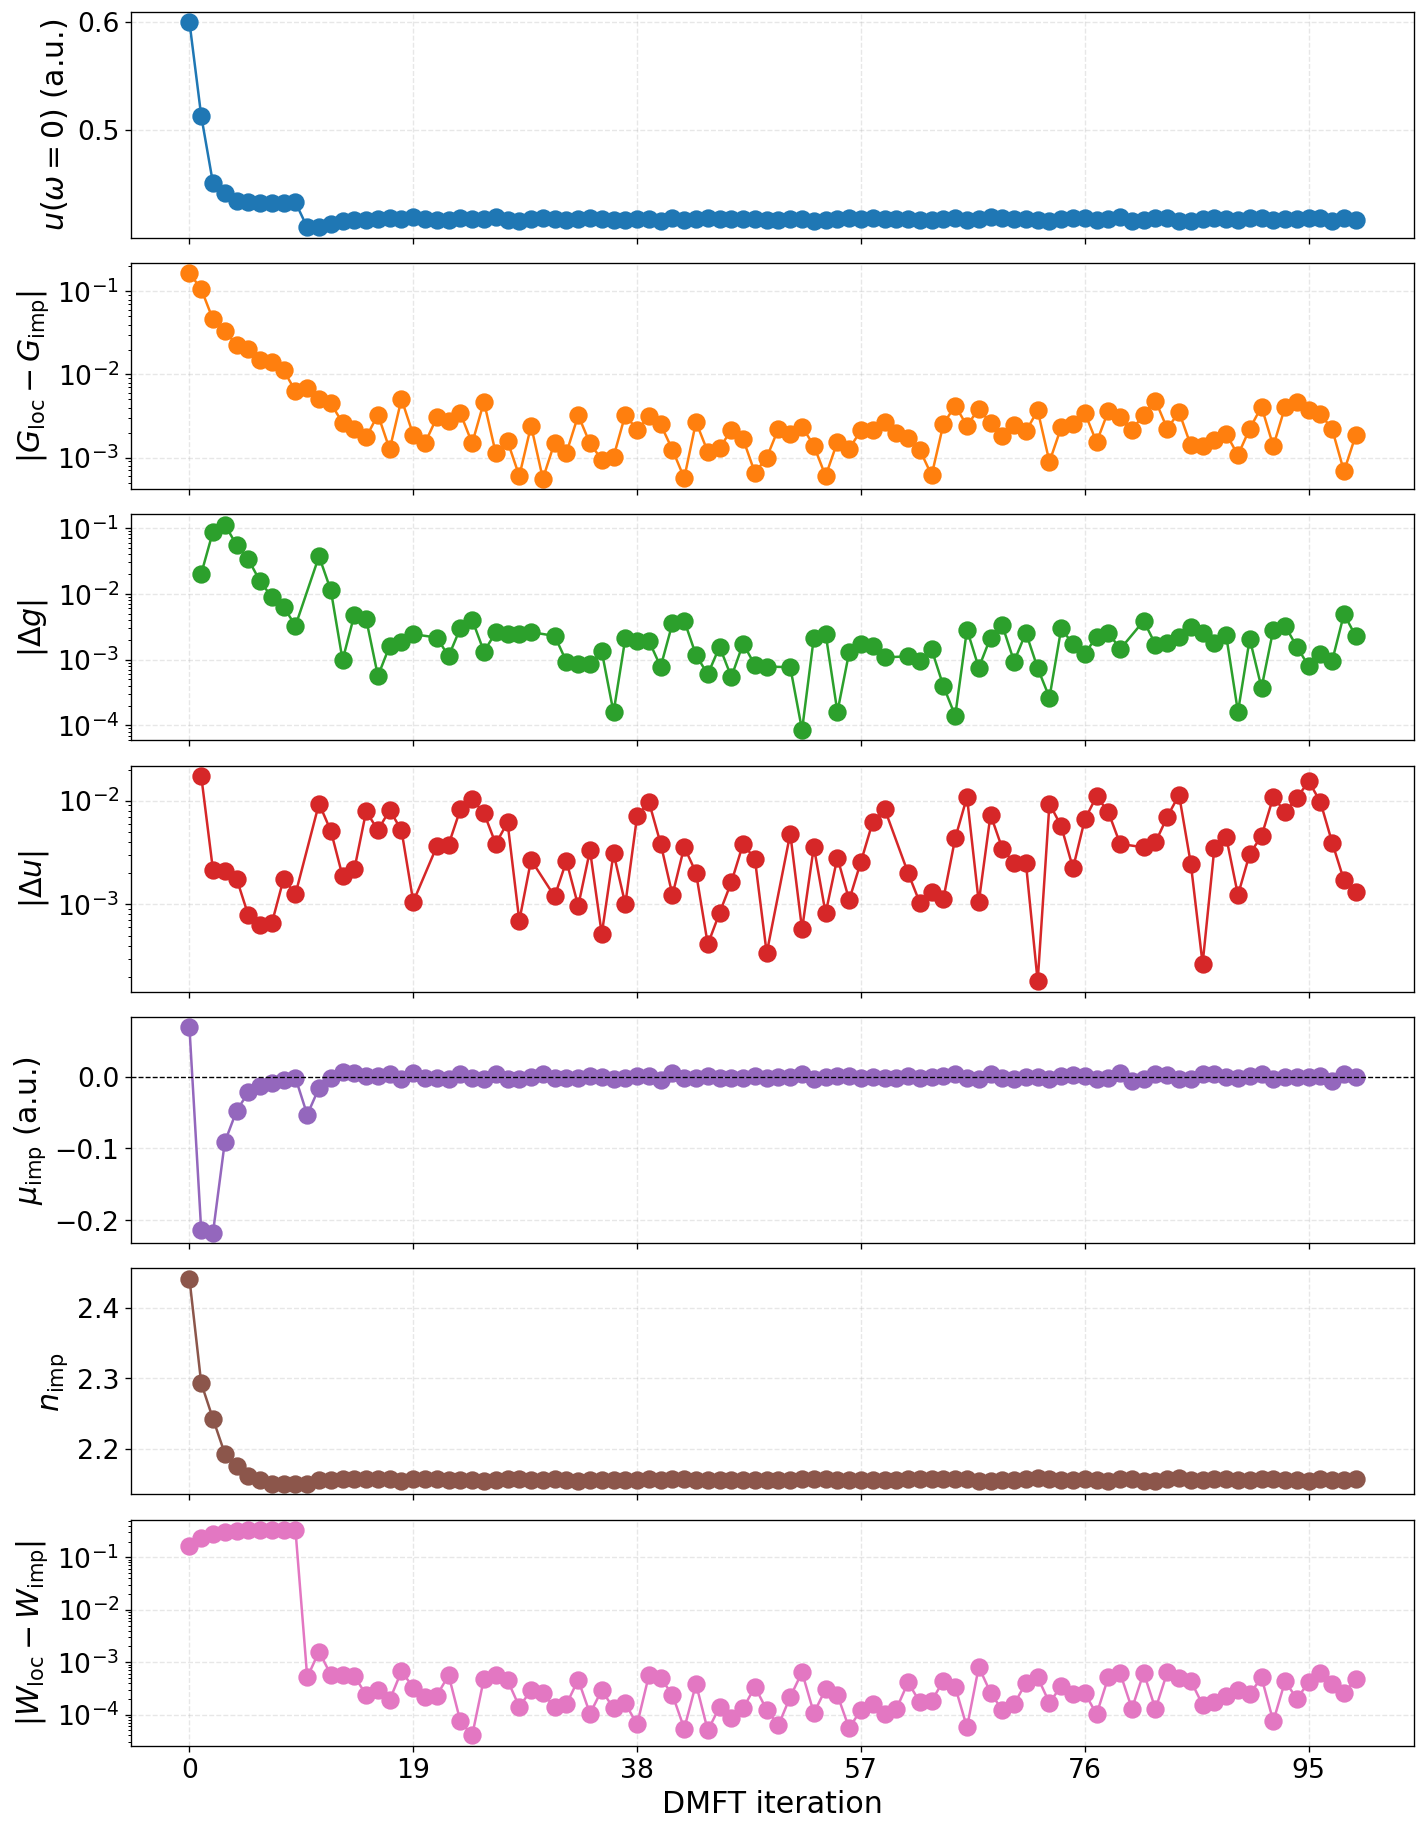

In [2]:
from IPython.display import display, Image

#dmft_chkpt = "nio_coqui_serious/nio.dmft.h5"
dmft_chkpt = "../../data/coqui/nio/555/nio.dmft.h5"
out_file = coqui.dmft.plot_edmft_convergence(dmft_chkpt, check_w=True)
display(Image(out_file, width=600))
#Image(out_file, width=600)

# this is needed for matplotlib to display plots in the remaining notebook cells (or workaround?)
%matplotlib inline 

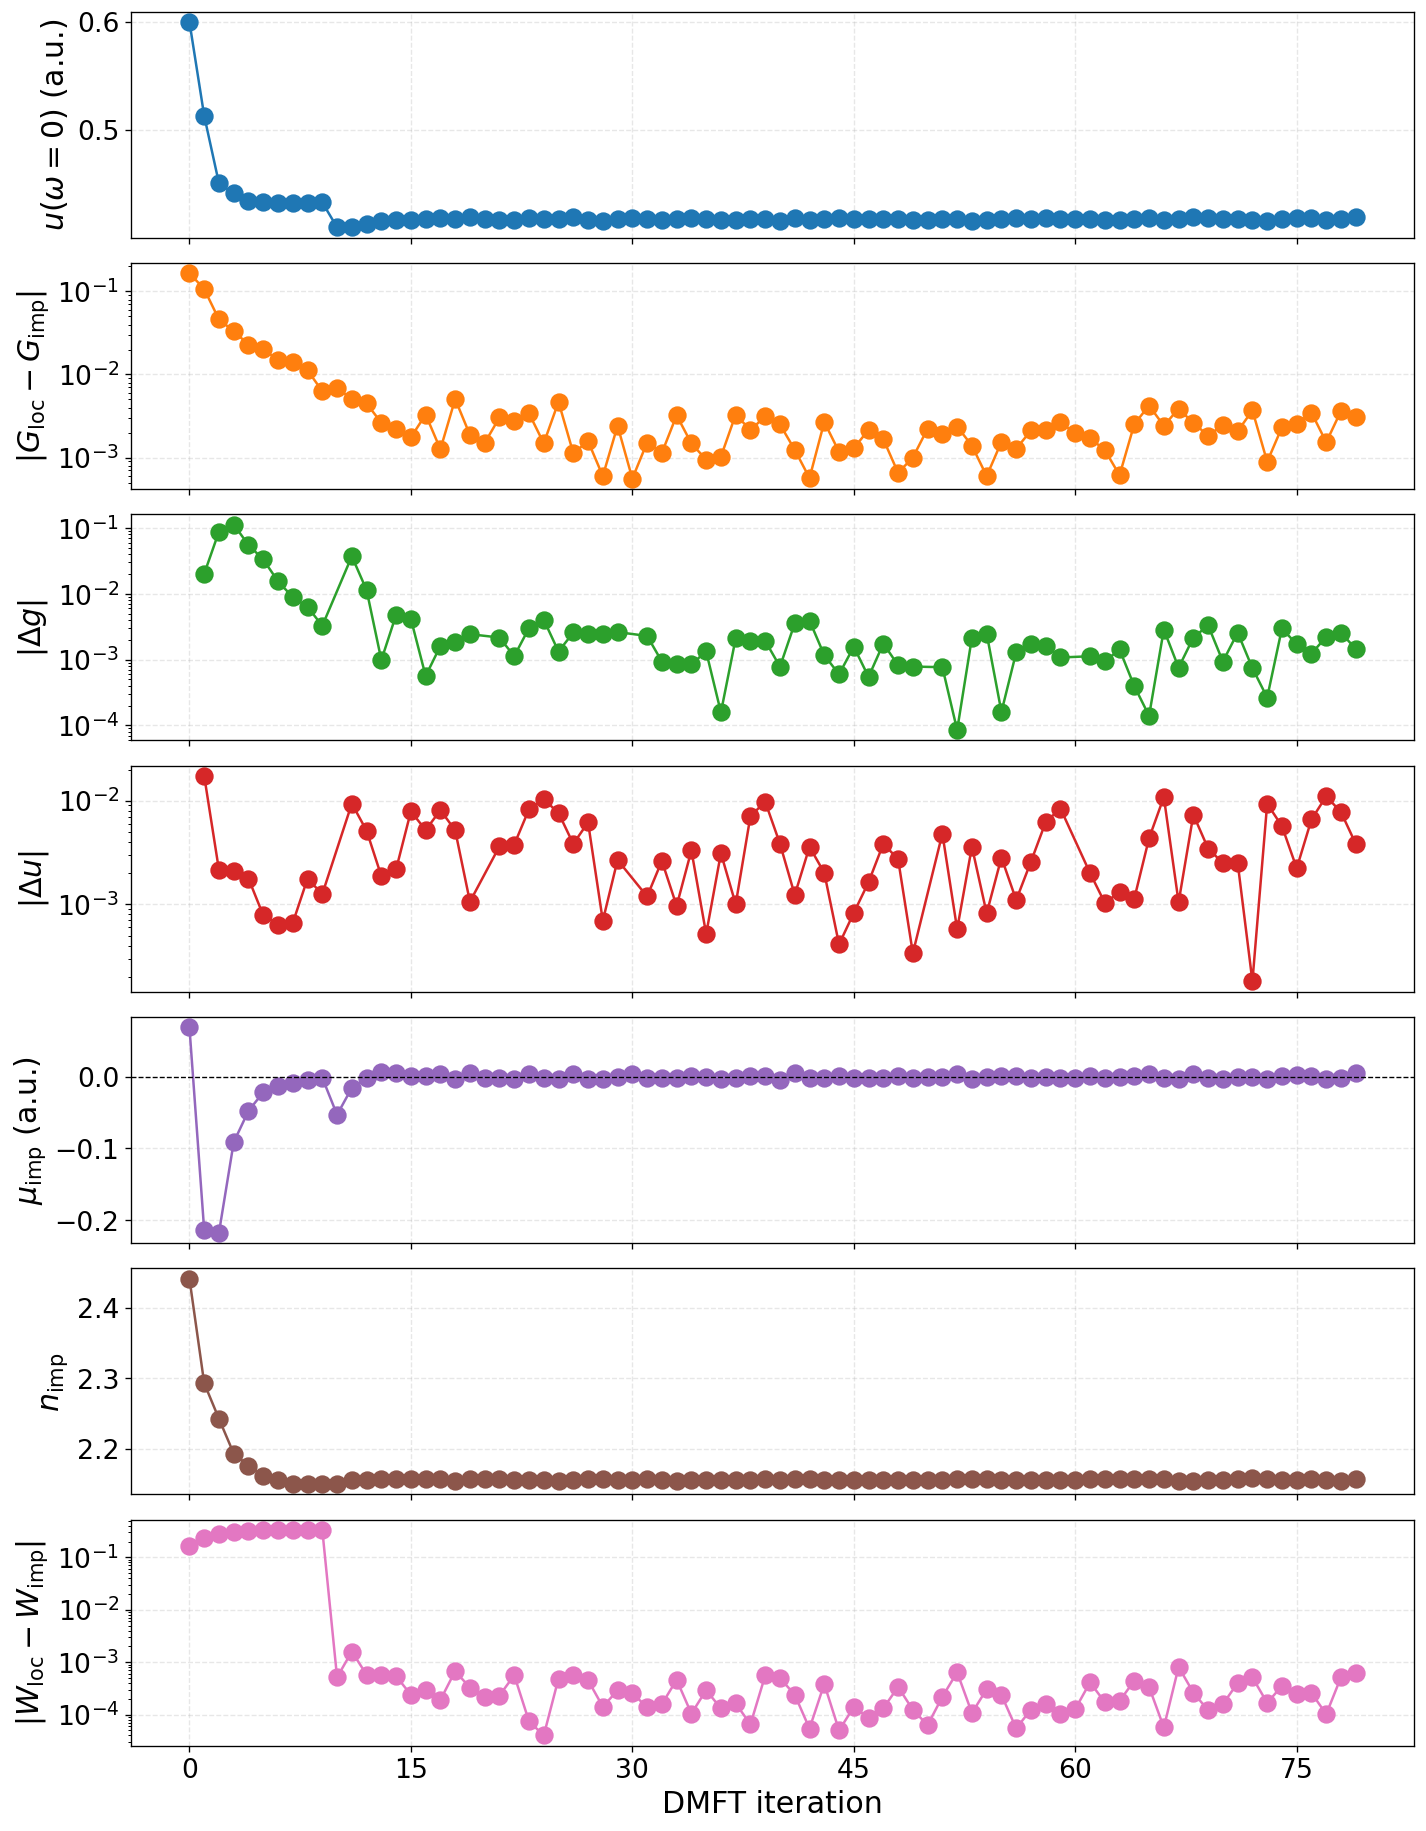

In [ ]:
from IPython.display import display, Image

#dmft_chkpt = "nio_coqui_serious/nio.dmft.h5"
dmft_chkpt = "../../data/coqui/nio/555/nio.dmft.h5"
out_file = coqui.dmft.plot_edmft_convergence(dmft_chkpt, check_w=True)
display(Image(out_file, width=600))
#Image(out_file, width=600)

# this is needed for matplotlib to display plots in the remaining notebook cells (or workaround?)
%matplotlib inline

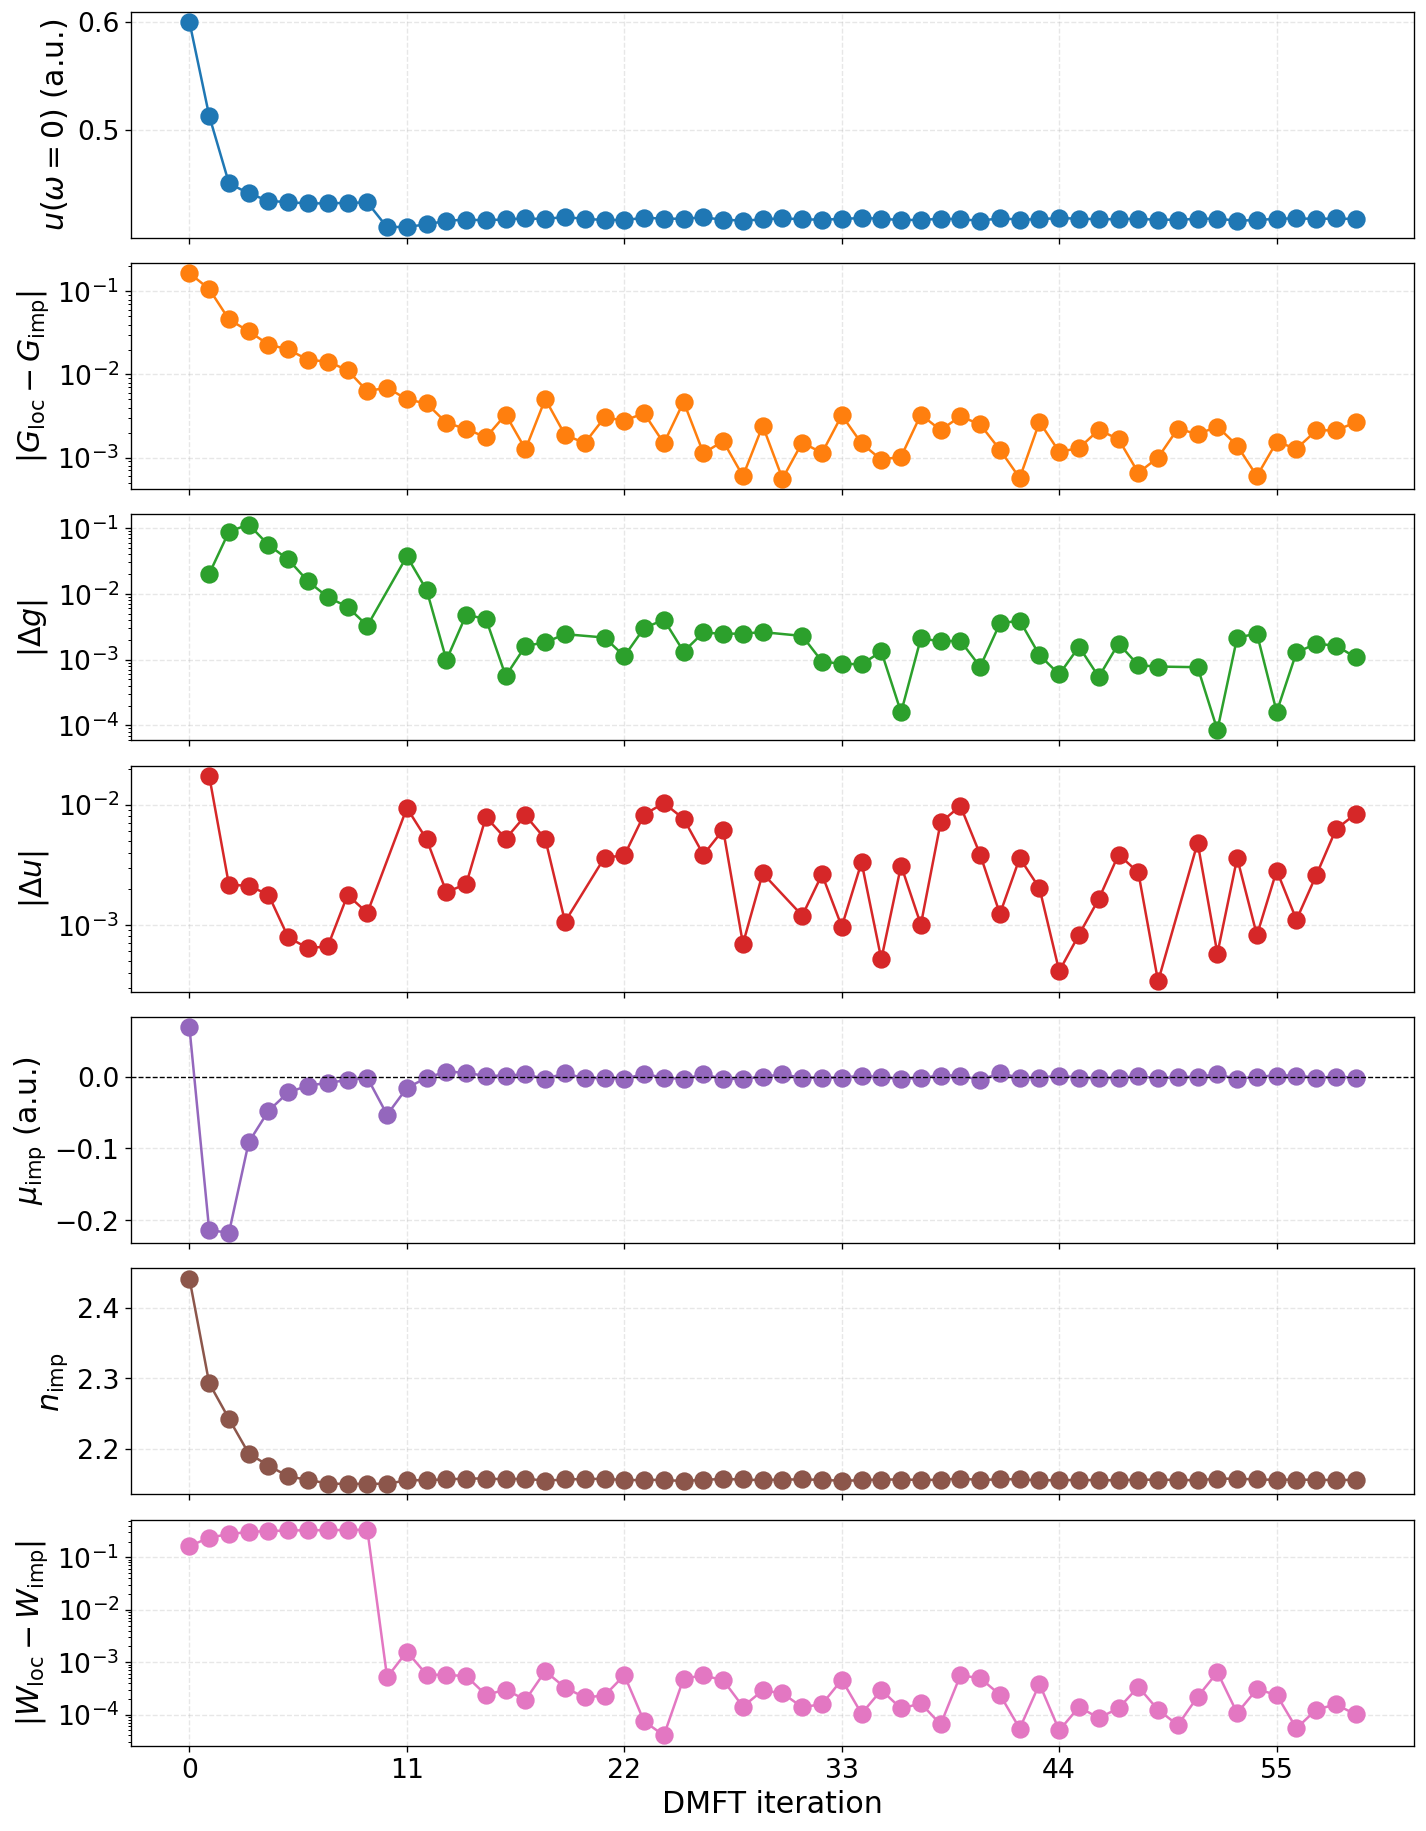

In [4]:
from IPython.display import display, Image

#dmft_chkpt = "nio_coqui_serious/nio.dmft.h5"
dmft_chkpt = "../../data/coqui/nio/555/nio.dmft.h5"
out_file = coqui.dmft.plot_edmft_convergence(dmft_chkpt, check_w=True)
display(Image(out_file, width=600))
#Image(out_file, width=600)

# this is needed for matplotlib to display plots in the remaining notebook cells (or workaround?)
%matplotlib inline 

A few features of the convergence figure above are worth reading off:

- **Two-stage screening.** This run used `rpa` screening for the first 10 iterations and switched on the self-consistent `gw_edmft` screening only afterwards. That is why $|\tilde{W}_{\mathrm{loc}} - \tilde{W}_{\mathrm{imp}}|$ stays large through the first 10 iterations — the lattice screened interaction is not yet being iterated against the impurity — and only starts to converge once the EDMFT polarization correction is turned on.

- **Charge stabilization.** The impurity occupation $n_{\mathrm{imp}}$ settles to a stable value while the auxiliary impurity chemical potential $\mu_{\mathrm{imp}}$ decays toward zero, signalling that the impurity charge has become consistent with the projected lattice value.

- **Self-energy vs. polarization.** Most of the change in $n_{\mathrm{imp}}$ is driven by the EDMFT correction to the *self-energy*; once the EDMFT correction to the *polarization* is also included (after iteration 10), the occupation barely moves. For NiO, the local self-energy correction is the dominant effect on the charge distribution.

[TODO: Mention the oscillations in the late iterations as a consequence of slow convergecne of the divergent impurity self-energy]

### Section 2: Analysis of GW+EDMFT results

In the previous section, we initialized a short GW+EDMFT workflow for NiO and identified where the main lattice and impurity quantities are stored. In this section, we will analyze results from a more converged NiO checkpoint and compare how spectral functions, self-energies, and screened interactions evolve relative to the GW starting point.

In [2]:
dmft_chkpt = "../../data/coqui/nio/555/nio.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_chkpt)
imp_inputs = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="inputs", iteration=0)[0]
imp_results = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="results", iteration=-1)[0]

print("Keys in impurity inputs dictionary:")
print(imp_inputs.keys())
print("\nKeys in impurity results dictionary:")
print(imp_results.keys())

Keys in impurity inputs dictionary:
dict_keys(['Gloc_t', 'Vloc', 'Wloc_t', 'delta_iw', 'g_weiss_iw', 'gf_struct', 'h0', 'u_weiss_iw'])

Keys in impurity results dictionary:
dict_keys(['Chi_iw', 'G_iw', 'G_iw_data', 'Pi_iw', 'Pi_iw_data', 'Pi_iw_dc_data', 'Sigma_infty', 'Sigma_infty_dc', 'Sigma_iw', 'Sigma_iw_data', 'Sigma_iw_dc_data', 'W_iw', 'W_iw_data', 'average_order', 'average_sign', 'convergence', 'density', 'gf_struct', 'mu_imp', 'orbital_occupations'])


#### 🔹 Impurity v.s. double-counting self-energy


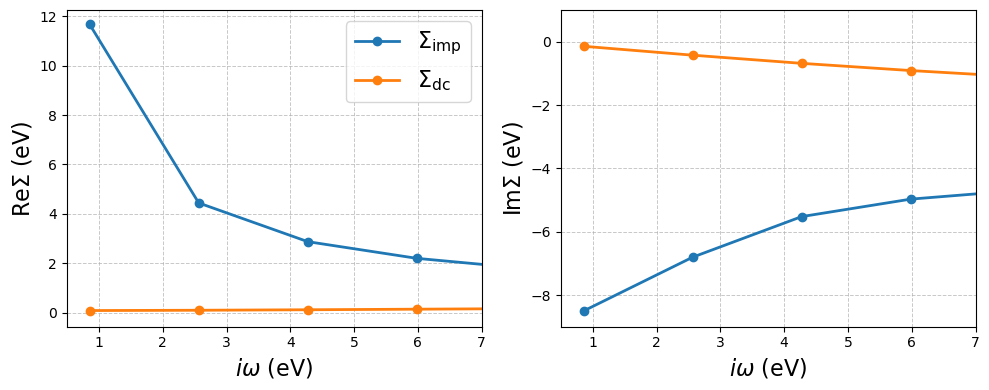

In [3]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV
Sigma_imp_iw = imp_results['Sigma_iw_data'][0][iw_mesh_f>0,0,0] * Hartree_eV
Sigma_dc_iw = imp_results['Sigma_iw_dc_data'][0][iw_mesh_f>0,0,0] * Hartree_eV
iw_mesh_f = iw_mesh_f[iw_mesh_f>0]

fig, ax = plt.subplots(1, 2, figsize=(10,4), dpi=100)
offset = 0
ax[0].plot(iw_mesh_f, Sigma_imp_iw.real, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label='$\Sigma_{\mathrm{imp}}$')
ax[0].plot(iw_mesh_f, Sigma_dc_iw.real, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label='$\Sigma_{\mathrm{dc}}$')
ax[1].plot(iw_mesh_f, Sigma_imp_iw.imag, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label='$\Sigma_{\mathrm{imp}}$')
ax[1].plot(iw_mesh_f, Sigma_dc_iw.imag, 
     linestyle='-', marker='o', markersize=6, linewidth=2, 
     label='$\Sigma_{\mathrm{dc}}$')

ax[0].set_xlim(0.5, 7.0)
ax[0].set_xlabel("$i\omega$ (eV)", fontsize=16)
ax[0].set_ylabel("Re$\Sigma$ (eV)", fontsize=16)
ax[0].legend(loc=1, ncol=1, fontsize=16)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

ax[1].set_xlim(0.5, 7.0)
ax[1].set_ylim(-9.0, 1.0)
ax[1].set_xlabel("$i\omega$ (eV)", fontsize=16)
ax[1].set_ylabel("Im$\Sigma$ (eV)", fontsize=16)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
plt.show()

#### 🔹 Local spectral functions: GW v.s. GW+EDMFT v.s. Expt

In [55]:
Gloc_iw_gw = iaft.tau_to_w(imp_inputs["Gloc_t"][0], stats='fermion')
Gimp_iw = imp_results["G_iw_data"][0]

#Gw_gw, w_mesh = coqui.post_proc.aaa_adapol(Gloc_iw_gw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=40, eta=0.02)
#Gw, w_mesh = coqui.post_proc.aaa_adapol(Gimp_iw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=40, eta=0.02)
Gw_gw, w_mesh = coqui.post_proc.pade(Gloc_iw_gw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=100, eta=0.005)
Gw, w_mesh = coqui.post_proc.pade(Gimp_iw, iaft, stats='fermion', wmin=-0.3, wmax=0.20, Nw=1000, Nfit=100, eta=0.005)

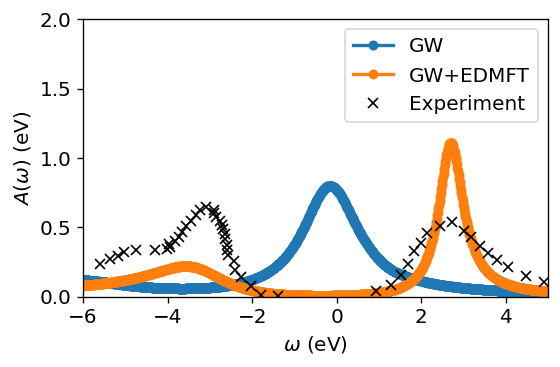

In [56]:
tot_pes = np.load("../../data/coqui/nio/555/nio_pes.npy")
tot_xas = np.load("../../data/coqui/nio/555/nio_xas.npy")

fig, ax = plt.subplots(1, figsize=(5,3), dpi=120)
ax.plot(w_mesh.real * Hartree_eV, -Gw_gw[:,0,0].imag / Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW')
ax.plot(w_mesh.real * Hartree_eV, -Gw[:,0,0].imag / Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW+EDMFT')
ax.plot(tot_pes[:,0], tot_pes[:,1]*0.5, color='black', marker='x', linestyle='', label='Experiment')
ax.plot(tot_xas[:,0], tot_xas[:,1], color='black', marker='x', linestyle='')

ax.set_xlim(-6.0, 5.0)
ax.set_ylim(0, 2.0)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$\omega$ (eV)', fontsize=12)
ax.set_ylabel('$A(\omega)$ (eV)', fontsize=12)
ax.legend(fontsize=12)
plt.show()

#### 🔹 Local spectrum of the impurity screened interaction

In [73]:
import numpy as np
import coqui

dmft_chkpt = "../../data/coqui/nio/555/nio.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_chkpt)
imp_inputs = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="inputs", iteration=0)[0]
imp_results = coqui.dmft.read_impurity_chkpt(dmft_chkpt, read="results", iteration=-1)[0]

Vloc = imp_inputs["Vloc"][0,0,0,0]
Wloc_iw_gw = iaft.tau_to_w_phsym(imp_inputs["Wloc_t"], 'boson')[:,0,0,0,0]
Wimp_iw = imp_results["W_iw_data"][0][:,0,0]

#Wloc_w_gw, w_mesh = coqui.post_proc.pade(
#    Wloc_iw_gw, iaft, stats='boson', wmin=0.0, wmax=2.0, Nw=1000, Nfit=50, eta=0.005, ph_sym=True
#)
#Wimp_w, w_mesh = coqui.post_proc.pade(
#    Wimp_iw, iaft, stats='boson', wmin=0.0, wmax=2.0, Nw=1000, Nfit=50, eta=0.005, ph_sym=True
#)

Wloc_w_gw, w_mesh = coqui.post_proc.aaa_adapol(
    Wloc_iw_gw, iaft, stats='boson',wmin=0.0, wmax=2.0, Nw=1000, Nfit=40, ph_sym=True
)
Wimp_w, w_mesh = coqui.post_proc.aaa_adapol(
    Wimp_iw, iaft, stats='boson',wmin=0.0, wmax=2.0, Nw=1000, Nfit=40, ph_sym=True
)

/mnt/home/cyeh/py_env/py311_mod2.4/lib/python3.11/site-packages/cvxpy/expressions/constants/constant.py:52: UserWarning: Initializing a Constant with a nested list is undefined behavior. Consider using a numpy array instead.
  warnings.warn(NESTED_LIST_WARNING)


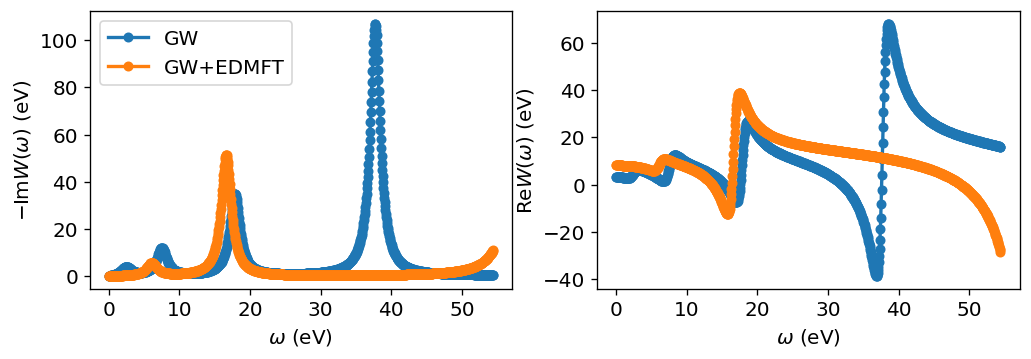

In [74]:
import matplotlib.pyplot as plt
Hartree_eV = 27.211386245988

fig, ax = plt.subplots(1, 2, figsize=(10,3), dpi=120)
ax[0].plot(w_mesh.real * Hartree_eV, -Wloc_w_gw.imag * Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW')
ax[0].plot(w_mesh.real * Hartree_eV, -Wimp_w.imag * Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW+EDMFT')
ax[1].plot(w_mesh.real * Hartree_eV, (Wloc_w_gw+Vloc).real * Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW')
ax[1].plot(w_mesh.real * Hartree_eV, (Wimp_w+Vloc).real * Hartree_eV,
        linewidth=2, marker='o', markersize=5, label='GW+EDMFT')

#ax.set_xlim(0.0, 30.0)
#ax.set_ylim(0, 10.0)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel('$\omega$ (eV)', fontsize=12)
ax[0].set_ylabel('$-\mathrm{Im}W(\omega)$ (eV)', fontsize=12)
ax[0].legend(fontsize=12)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[1].set_xlabel('$\omega$ (eV)', fontsize=12)
ax[1].set_ylabel('$\mathrm{Re}W(\omega)$ (eV)', fontsize=12)
#ax[1].legend(fontsize=12)
plt.show()

#### 🔹 Effective interactions and its comparison with cRPA